# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.

**You must use quantitative visualizations (boxplots or histograms) when comparing quantitative features.  DO NOT categorize quantitative features.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('loan_data.csv')

# Display first few rows
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71,male,Associate,46817.176426,3,RENT,11567.737650,MEDICAL,10.351469,0.247083,5,806.869094,No,0
1,34,male,High School,79093.494008,17,OWN,9519.674498,MEDICAL,11.168902,0.120360,1,604.330171,No,0
2,80,male,Associate,67819.614431,20,OWN,16226.604002,PERSONAL,12.293112,0.239261,11,685.933579,No,0
3,40,female,Associate,49599.861220,0,RENT,15641.221708,VENTURE,10.327926,0.315348,14,629.190150,No,0
4,43,male,Doctorate,99833.900180,8,OWN,12727.942517,EDUCATION,9.338069,0.127491,16,638.298168,No,1


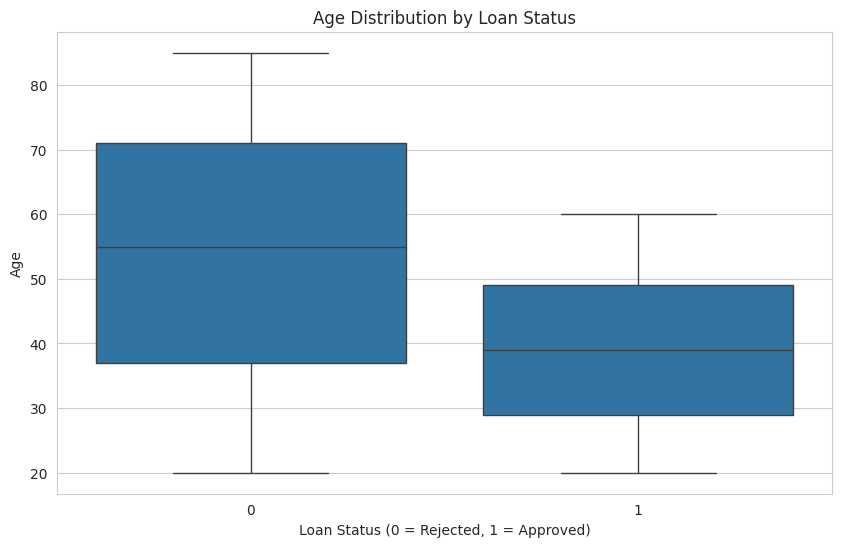

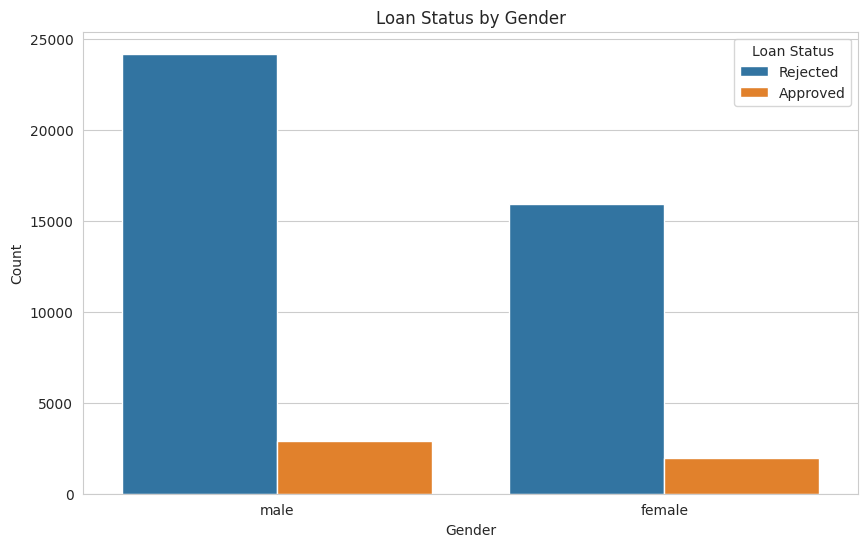

Approval rates by gender:
person_gender
female    0.110280
male      0.107711
Name: loan_status, dtype: float64


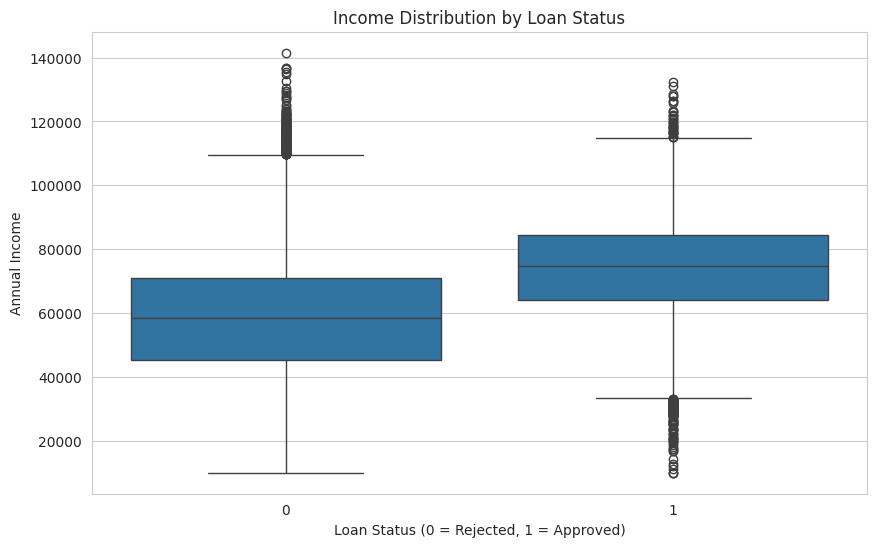

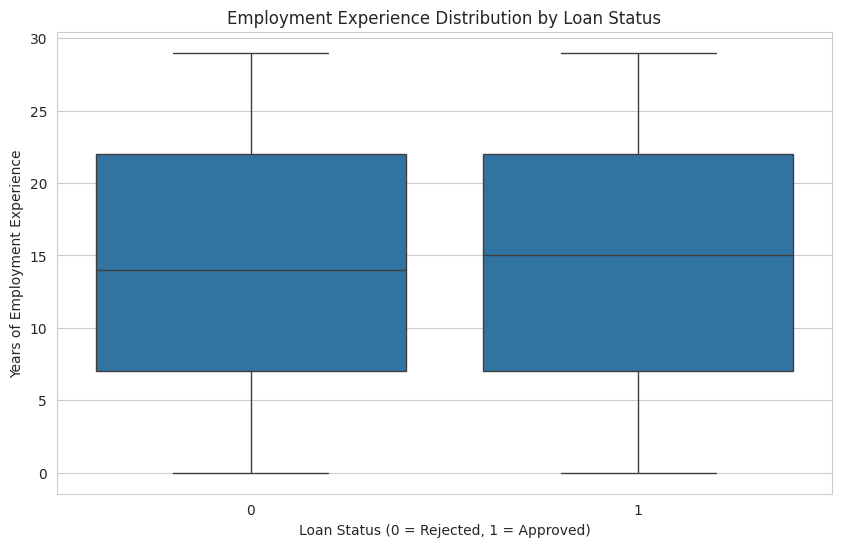

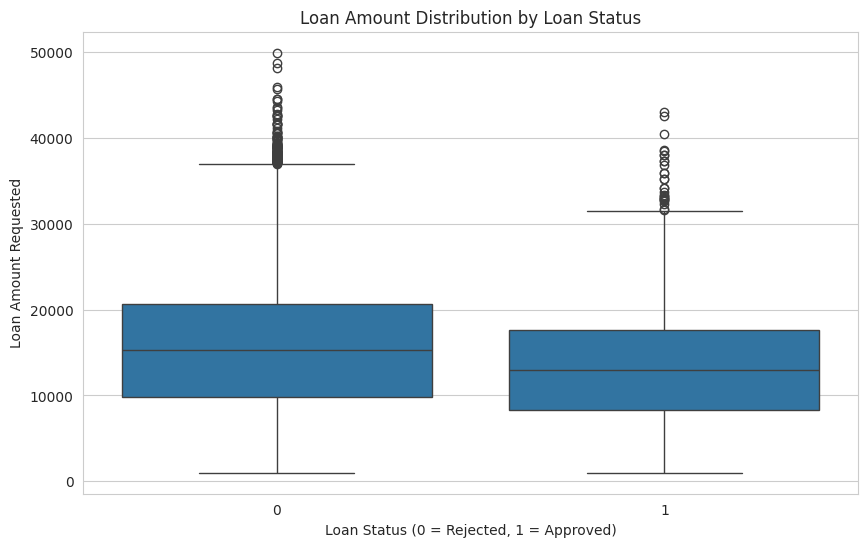

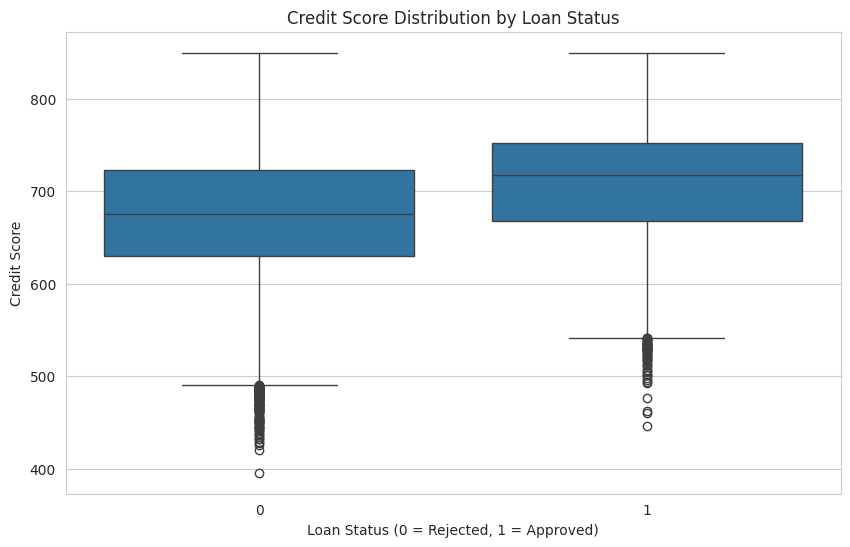

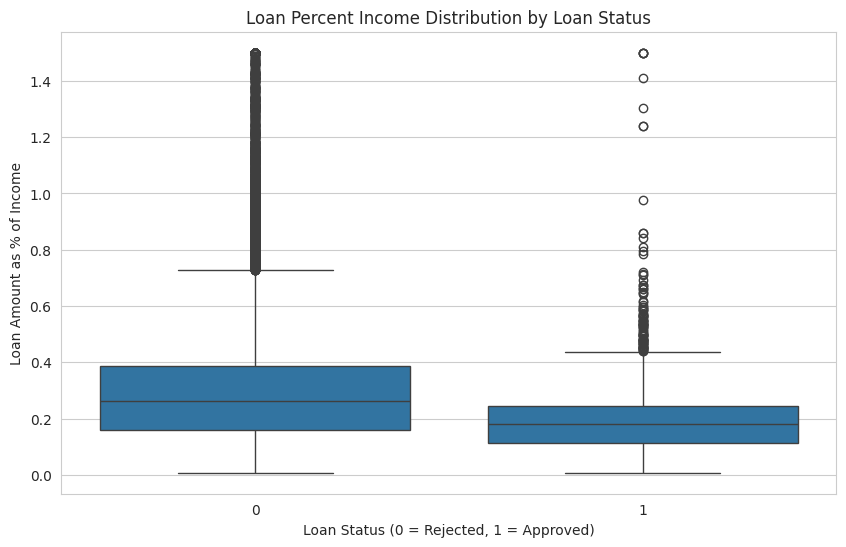

In [2]:
# Set up the plotting style
sns.set_style('whitegrid')

# 1. Visualize relationship between age and loan_status
plt.figure(figsize=(10, 6))
sns.boxplot(x='loan_status', y='person_age', data=df)
plt.title('Age Distribution by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Age')
plt.show()

# 2. Visualize relationship between sex and loan_status
plt.figure(figsize=(10, 6))
sns.countplot(x='person_gender', hue='loan_status', data=df)
plt.title('Loan Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Loan Status', labels=['Rejected', 'Approved'])
plt.show()

# Calculate approval rates by gender
approval_by_gender = df.groupby('person_gender')['loan_status'].mean()
print("Approval rates by gender:")
print(approval_by_gender)

# 3. Visualize relationship between person_income and loan_status
plt.figure(figsize=(10, 6))
sns.boxplot(x='loan_status', y='person_income', data=df)
plt.title('Income Distribution by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Annual Income')
plt.show()

# 4. Visualize relationship between person_emp_exp and loan_status
plt.figure(figsize=(10, 6))
sns.boxplot(x='loan_status', y='person_emp_exp', data=df)
plt.title('Employment Experience Distribution by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Years of Employment Experience')
plt.show()

# 5. Visualize relationship between loan_amnt and loan_status
plt.figure(figsize=(10, 6))
sns.boxplot(x='loan_status', y='loan_amnt', data=df)
plt.title('Loan Amount Distribution by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Loan Amount Requested')
plt.show()

# 6. Visualize relationship between credit_score and loan_status
plt.figure(figsize=(10, 6))
sns.boxplot(x='loan_status', y='credit_score', data=df)
plt.title('Credit Score Distribution by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Credit Score')
plt.show()

# 7. Visualize relationship between loan_percent_income and loan_status
plt.figure(figsize=(10, 6))
sns.boxplot(x='loan_status', y='loan_percent_income', data=df)
plt.title('Loan Percent Income Distribution by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Loan Amount as % of Income')
plt.show()

Approval rates by age group:
age_group
<25      0.186379
25-34    0.173862
35-44    0.182621
45-54    0.163314
55+      0.028184
Name: loan_status, dtype: float64


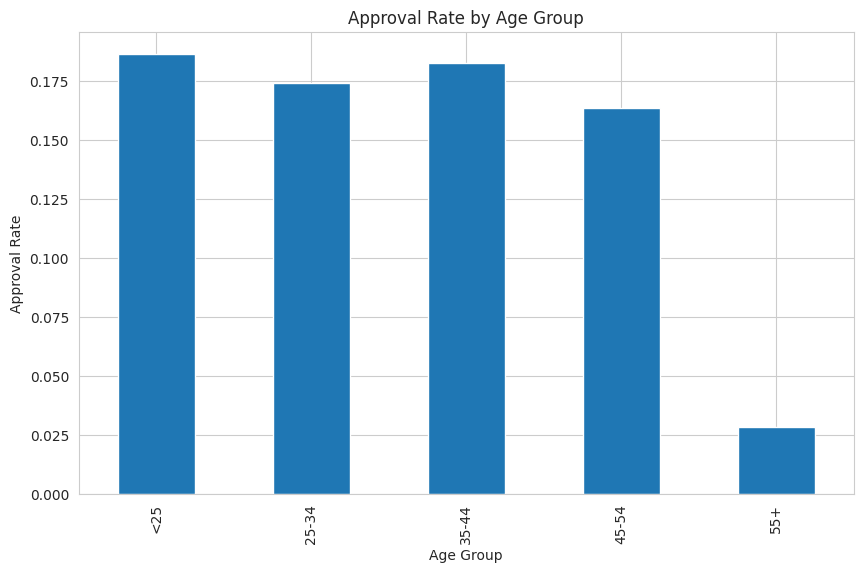

Approval rates by gender and age group:
age_group           <25     25-34     35-44     45-54       55+
person_gender                                                  
female         0.188714  0.174581  0.183352  0.168105  0.028136
male           0.184826  0.173366  0.182145  0.160158  0.028215


<Figure size 1000x600 with 0 Axes>

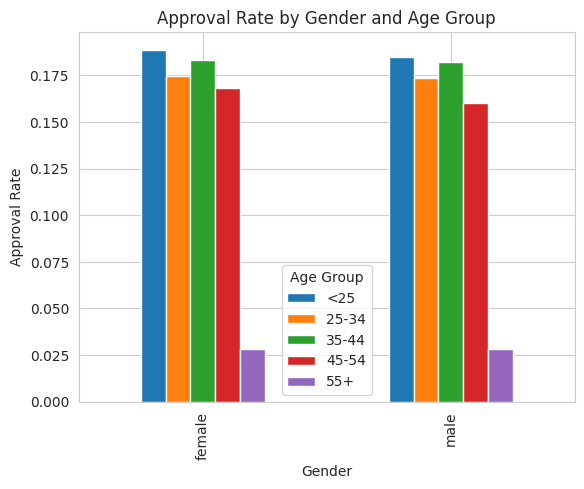

In [3]:
# Additional analysis: Approval rates by age groups
df['age_group'] = pd.cut(df['person_age'], bins=[0, 25, 35, 45, 55, 100], labels=['<25', '25-34', '35-44', '45-54', '55+'])
approval_by_age = df.groupby('age_group')['loan_status'].mean()
print("Approval rates by age group:")
print(approval_by_age)

plt.figure(figsize=(10, 6))
approval_by_age.plot(kind='bar')
plt.title('Approval Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Approval Rate')
plt.show()

# Approval rates by gender and age group
approval_by_gender_age = df.groupby(['person_gender', 'age_group'])['loan_status'].mean().unstack()
print("Approval rates by gender and age group:")
print(approval_by_gender_age)

plt.figure(figsize=(10, 6))
approval_by_gender_age.plot(kind='bar')
plt.title('Approval Rate by Gender and Age Group')
plt.xlabel('Gender')
plt.ylabel('Approval Rate')
plt.legend(title='Age Group')
plt.show()

## Analysis

Based on the visualizations:

- **Age**: The boxplot shows that approved loans have a slightly lower median age than rejected ones. However, the approval rate analysis reveals a significant disparity: individuals aged 55+ have an approval rate of only 2.8%, compared to 16-18% for younger age groups. This indicates potential age discrimination, particularly against older applicants.

- **Sex**: The count plot shows similar distributions of approvals and rejections across genders. The approval rates are nearly identical (female: 11.0%, male: 10.8%), and when broken down by age groups, the rates remain very close. There is no evidence of gender discrimination.

- **Person Income**: The boxplot indicates that approved applicants have higher median incomes than rejected ones, suggesting income is a positive factor in loan approval.

- **Person Employment Experience**: Approved applicants tend to have more years of employment experience, as shown by the higher median in the boxplot.

- **Loan Amount**: The distributions are similar, but approved loans might have slightly lower amounts, though the difference is not stark.

- **Credit Score**: Approved applicants have significantly higher credit scores, with a much higher median, indicating credit score is a strong driver of approval.

- **Loan Percent Income**: Approved loans have lower percentages of income, meaning the loan amount is a smaller portion of their income, which makes sense for approval.

**Features that drive the model's decision**: Credit score, income, employment experience, loan percent income, and age (negatively for older ages).

**Unrelated features**: Sex appears unrelated to loan status.

**Concern about legal trouble**: Yes, the financial institution should be concerned about potential age discrimination, as older applicants (55+) are approved at much lower rates than younger ones, which could violate fair lending laws. No concerns for gender discrimination based on the data.